In [1]:
import sqlite3
import pandas as pd

In [2]:
connection = sqlite3.connect(
    "../data/datapulse.db"
)

In [3]:
query = """
SELECT *
FROM sales
LIMIT 5;
"""

pd.read_sql_query(
    query,
    connection
)

,order_id,order_date,customer_id,product,category,region,quantity,unit_price,discount,payment_method,returned,gross_sales,discount_amount,net_sales,year,month,month_name,day_name
0,O00001,2025-01-01 00:00:00,C0017,Headphones,Accessories,North,3,2500,0.00,Credit Card,No,7500,0.0,7500.0,2025,1,January,Wednesday
1,O00002,2025-01-01 02:36:59.483896,C0056,Monitor,Electronics,East,4,15000,0.00,Credit Card,No,60000,0.0,60000.0,2025,1,January,Wednesday
2,O00003,2025-01-01 05:13:58.967793,C0182,Laptop,Electronics,North,2,65000,0.05,Cash,No,130000,6500.0,123500.0,2025,1,January,Wednesday
3,O00004,2025-01-01 07:50:58.451690,C0144,Laptop,Electronics,East,3,65000,0.10,Debit Card,No,195000,19500.0,175500.0,2025,1,January,Wednesday
4,O00005,2025-01-01 10:27:57.935587,C0319,Laptop,Electronics,West,1,65000,0.00,Debit Card,No,65000,0.0,65000.0,2025,1,January,Wednesday


In [4]:
# sales from the North region.
query = """
SELECT
    order_id,
    customer_id,
    product,
    region,
    net_sales
FROM sales
WHERE region = 'North';
"""

north_sales = pd.read_sql_query(
    query,
    connection
)

north_sales.head()

,order_id,customer_id,product,region,net_sales
0,O00001,C0017,Headphones,North,7500.0
1,O00003,C0182,Laptop,North,123500.0
2,O00006,C0358,Keyboard,North,3800.0
3,O00011,C0405,Monitor,North,15000.0
4,O00014,C0173,Monitor,North,40500.0


In [5]:
# Q) How much revenue came from the North region?
query = """
SELECT
    SUM(net_sales) AS north_revenue
FROM sales
WHERE region = 'North';
"""

north_revenue = pd.read_sql_query(
    query,
    connection
)

north_revenue

,north_revenue
0,67614895.0


In [6]:
# Q) Find sales from North where the discount is greater than 10%.
query = """
SELECT
    order_id,
    product,
    region,
    discount,
    net_sales
FROM sales
WHERE region = 'North'
AND discount > 10;
"""

north_discounted = pd.read_sql_query(
    query,
    connection
)

north_discounted.head()

,order_id,product,region,discount,net_sales


In [7]:
# Q) How much revenue came from North orders with discounts above 10%?
query = """
SELECT
    SUM(net_sales) AS revenue
FROM sales
WHERE region = 'North'
AND discount > 10;
"""

pd.read_sql_query(
    query,
    connection
)

,revenue
0,None


In [8]:
# Q) Find orders from either North or South.
query = """
SELECT
    order_id,
    region,
    product,
    net_sales
FROM sales
WHERE region = 'North'
OR region = 'South';
"""

north_south = pd.read_sql_query(
    query,
    connection
)

north_south.head()

,order_id,region,product,net_sales
0,O00001,North,Headphones,7500.0
1,O00003,North,Laptop,123500.0
2,O00006,North,Keyboard,3800.0
3,O00009,South,Laptop,61750.0
4,O00010,South,Monitor,75000.0


In [9]:
# IN
query = """
SELECT
    order_id,
    region,
    product,
    net_sales
FROM sales
WHERE region IN ('North', 'South');
"""

pd.read_sql_query(
    query,
    connection
)


,order_id,region,product,net_sales
0,O00001,North,Headphones,7500.0
1,O00003,North,Laptop,123500.0
2,O00006,North,Keyboard,3800.0
3,O00009,South,Laptop,61750.0
4,O00010,South,Monitor,75000.0
...,...,...,...,...
2503,O04991,South,Headphones,6750.0
2504,O04992,South,Tablet,30000.0
2505,O04997,North,Mouse,3800.0
2506,O04999,North,Keyboard,3600.0


In [10]:
# Q) Compare North + South revenue
query = """
SELECT
    region,
    SUM(net_sales) AS revenue
FROM sales
WHERE region IN ('North', 'South')
GROUP BY region
ORDER BY revenue DESC;
"""

north_south_revenue = pd.read_sql_query(
    query,
    connection
)

north_south_revenue

,region,revenue
0,South,69978440.0
1,North,67614895.0


In [11]:
# Q) BETWEEN
query = """
SELECT
    order_id,
    order_date,
    product,
    net_sales
FROM sales
WHERE order_date BETWEEN '2025-01-01'
                      AND '2025-03-31';
"""

q1_sales = pd.read_sql_query(
    query,
    connection
)

q1_sales.head()

,order_id,order_date,product,net_sales
0,O00001,2025-01-01 00:00:00,Headphones,7500.0
1,O00002,2025-01-01 02:36:59.483896,Monitor,60000.0
2,O00003,2025-01-01 05:13:58.967793,Laptop,123500.0
3,O00004,2025-01-01 07:50:58.451690,Laptop,175500.0
4,O00005,2025-01-01 10:27:57.935587,Laptop,65000.0


In [12]:
# Q) What was Q1 revenue?
query = """
SELECT
    SUM(net_sales) AS q1_revenue
FROM sales
WHERE order_date BETWEEN '2025-01-01'
                      AND '2025-03-31';
"""

q1_revenue = pd.read_sql_query(
    query,
    connection
)

q1_revenue

,q1_revenue
0,46073175.0


In [13]:
# LIKE
query = """
SELECT
    product,
    SUM(net_sales) AS revenue
FROM sales
WHERE product LIKE '%Pro%'
GROUP BY product
ORDER BY revenue DESC;
"""

pro_products = pd.read_sql_query(
    query,
    connection
)

pro_products

,product,revenue


In [14]:
# Q) Which products generated more than ₹X?
query = """
SELECT
    product,
    SUM(net_sales) AS revenue
FROM sales
GROUP BY product
ORDER BY revenue DESC;
"""

product_revenue = pd.read_sql_query(
    query,
    connection
)

product_revenue

,product,revenue
0,Laptop,115261250.0
1,Smartphone,71852000.0
2,Tablet,50097000.0
3,Monitor,26736750.0
4,Webcam,6120625.0
5,Headphones,4321375.0
6,Keyboard,3398100.0
7,Mouse,1307200.0


In [15]:
# meedian of it 
revenue_threshold = product_revenue["revenue"].median()

print(
    "Median Product Revenue:",
    round(revenue_threshold, 2)
)

Median Product Revenue: 16428687.5


In [16]:
query = f"""
SELECT
    product,
    SUM(net_sales) AS revenue
FROM sales
GROUP BY product
HAVING SUM(net_sales) > {revenue_threshold}
ORDER BY revenue DESC;
"""

high_revenue_products = pd.read_sql_query(
    query,
    connection
)

high_revenue_products

,product,revenue
0,Laptop,115261250.0
1,Smartphone,71852000.0
2,Tablet,50097000.0
3,Monitor,26736750.0


In [17]:
# Q) Which products generated more than the average product revenue?
query = """
SELECT
    AVG(product_revenue) AS average_revenue
FROM (
    SELECT
        product,
        SUM(net_sales) AS product_revenue
    FROM sales
    GROUP BY product
);
"""

average_product_revenue = pd.read_sql_query(
    query,
    connection
)

average_product_revenue

,average_revenue
0,34886787.5


In [18]:
# for value
avg_product_revenue = (
    average_product_revenue
    .loc[0, "average_revenue"]
)

print(
    "Average Product Revenue:",
    round(avg_product_revenue, 2)
)

Average Product Revenue: 34886787.5


In [19]:
query = f"""
SELECT
    product,
    SUM(net_sales) AS revenue
FROM sales
GROUP BY product
HAVING SUM(net_sales) > {avg_product_revenue}
ORDER BY revenue DESC;
"""

above_average_products = pd.read_sql_query(
    query,
    connection
)

above_average_products

,product,revenue
0,Laptop,115261250.0
1,Smartphone,71852000.0
2,Tablet,50097000.0


In [20]:
# Q) Which region generated more than the average regional revenue?
query = """
SELECT
    region,
    SUM(net_sales) AS revenue
FROM sales
GROUP BY region
HAVING SUM(net_sales) >
(
    SELECT AVG(region_revenue)
    FROM (
        SELECT
            region,
            SUM(net_sales) AS region_revenue
        FROM sales
        GROUP BY region
    )
)
ORDER BY revenue DESC;
"""

above_average_regions = pd.read_sql_query(
    query,
    connection
)

above_average_regions

,region,revenue
0,East,72130300.0
1,South,69978440.0


In [21]:
# Q) Which products generated more than the average product revenue in the North region while having an average discount above 5%?
query = """
SELECT
    product,
    SUM(net_sales) AS revenue,
    AVG(discount) AS average_discount,
    COUNT(DISTINCT order_id) AS orders
FROM sales
WHERE region = 'North'
GROUP BY product
HAVING SUM(net_sales) >
(
    SELECT AVG(product_revenue)
    FROM (
        SELECT
            product,
            SUM(net_sales) AS product_revenue
        FROM sales
        WHERE region = 'North'
        GROUP BY product
    )
)
AND AVG(discount) > 5
ORDER BY revenue DESC;
"""

north_high_value_products = pd.read_sql_query(
    query,
    connection
)

north_high_value_products

,product,revenue,average_discount,orders


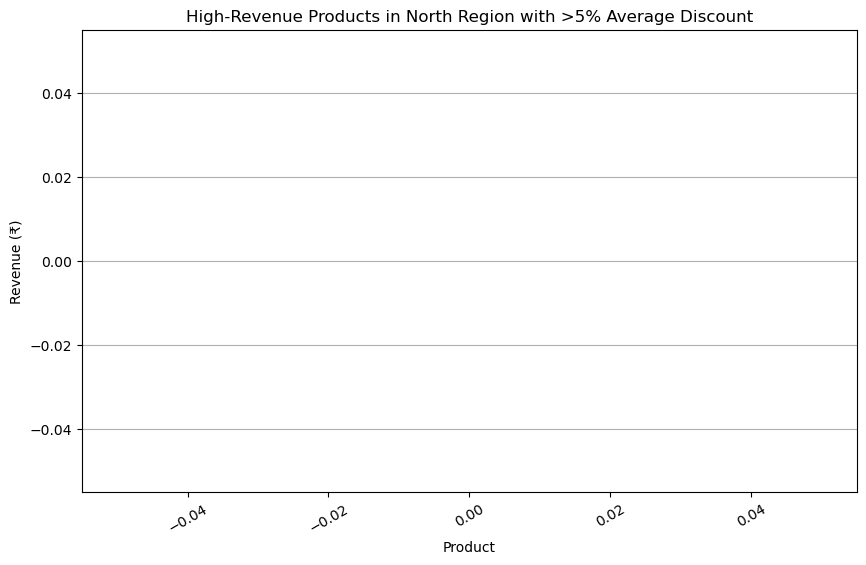

In [23]:
# Visualizing the result
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

plt.bar(
    north_high_value_products["product"],
    north_high_value_products["revenue"]
)

plt.title(
    "High-Revenue Products in North Region with >5% Average Discount"
)

plt.xlabel("Product")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=30)
plt.grid(axis="y")

plt.show()

In [24]:
# Insights 
print("=" * 70)
print("📊 DATAPULSE — DAY 17 SQL FILTERING INSIGHTS")
print("=" * 70)

print(
    f"\n1. NORTH REGION REVENUE:"
    f"\n₹{north_revenue.loc[0, 'north_revenue']:,.2f}"
)

print(
    f"\n2. Q1 REVENUE:"
    f"\n₹{q1_revenue.loc[0, 'q1_revenue']:,.2f}"
)

print(
    f"\n3. MEDIAN PRODUCT REVENUE:"
    f"\n₹{revenue_threshold:,.2f}"
)

print(
    f"\n4. PRODUCTS ABOVE MEDIAN REVENUE:"
    f"\n{len(high_revenue_products)} products"
)

if len(high_revenue_products) > 0:

    top_filtered_product = (
        high_revenue_products.iloc[0]
    )

    print(
        f"\n5. HIGHEST-REVENUE PRODUCT ABOVE MEDIAN:"
        f"\n{top_filtered_product['product']}"
        f"\nRevenue: ₹{top_filtered_product['revenue']:,.2f}"
    )

print(
    f"\n6. PRODUCTS ABOVE AVERAGE REVENUE:"
    f"\n{len(above_average_products)} products"
)

print(
    f"\n7. NORTH HIGH-VALUE + DISCOUNTED PRODUCTS:"
    f"\n{len(north_high_value_products)} products"
)

print("\n" + "=" * 70)

📊 DATAPULSE — DAY 17 SQL FILTERING INSIGHTS

1. NORTH REGION REVENUE:
₹67,614,895.00

2. Q1 REVENUE:
₹46,073,175.00

3. MEDIAN PRODUCT REVENUE:
₹16,428,687.50

4. PRODUCTS ABOVE MEDIAN REVENUE:
4 products

5. HIGHEST-REVENUE PRODUCT ABOVE MEDIAN:
Laptop
Revenue: ₹115,261,250.00

6. PRODUCTS ABOVE AVERAGE REVENUE:
3 products

7. NORTH HIGH-VALUE + DISCOUNTED PRODUCTS:
0 products

